# ADVANCED TIME SERIES FORECASTING PROJECT

This notebook presents an end-to-end forecasting pipeline for daily sales data from a French bakery dataset. The project begins with exploratory data analysis and baseline forecasting methods, then progresses to more advanced statistical models such as ARIMA and SARIMA. To improve predictive performance, exogenous variables like product price and engineered time-based features are also incorporated. The models are evaluated using holdout validation, rolling cross-validation, and multiple error metrics including MAE, RMSE, and SMAPE. Finally, the best-performing model is selected to generate future forecasts along with prediction intervals, providing both point estimates and uncertainty ranges.

In [1]:
# If running in Google Colab / fresh Jupyter environment, uncomment:
# !pip install statsforecast utilsforecast matplotlib pandas numpy

!pip install statsforecast utilsforecast

In [2]:
# 1. Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functools import partial

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    HistoricAverage,
    WindowAverage,
    SeasonalNaive,
    AutoARIMA,
)

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse, rmse, mape, smape, mase, scaled_crps
from utilsforecast.feature_engineering import fourier, time_features, pipeline

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [3]:
# 2. Configuration

DATA_URL = "https://raw.githubusercontent.com/marcopeix/youtube_tutorials/main/data/daily_sales_french_bakery.csv"

FREQ = "D"
HORIZON = 7
SEASON_LENGTH = 7
N_WINDOWS = 8
MIN_HISTORY = 28

ID_COL = "unique_id"
DATE_COL = "ds"
TARGET_COL = "y"

SELECTED_SERIES = ["BAGUETTE", "CROISSANT"]

In [4]:
# 3. Helper functions

def load_data(url: str) -> pd.DataFrame:
    """Load and clean bakery sales data."""
    df = pd.read_csv(url, parse_dates=[DATE_COL])
    df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

    # keep only time series with enough history
    df = df.groupby(ID_COL).filter(lambda x: len(x) >= MIN_HISTORY).copy()

    # numeric conversion
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    if "unit_price" in df.columns:
        df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

    # drop missing target
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    return df


def split_last_horizon(df: pd.DataFrame, horizon: int):
    """Last horizon observations of each series become test set."""
    test = df.groupby(ID_COL).tail(horizon).copy()
    train = df.drop(test.index).copy()
    return train.reset_index(drop=True), test.reset_index(drop=True)


def summarize_evaluation(eval_df: pd.DataFrame) -> pd.DataFrame:
    """Average metrics across series."""
    return (
        eval_df.drop(columns=[ID_COL])
        .groupby("metric")
        .mean()
        .reset_index()
    )


def plot_metric_bar(summary_df: pd.DataFrame, metric_name: str, title: str):
    """Simple metric bar plot."""
    row = summary_df[summary_df["metric"] == metric_name]
    methods = row.columns[1:].tolist()
    values = row.iloc[0, 1:].tolist()

    plt.figure(figsize=(10, 5))
    bars = plt.bar(methods, values)

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    plt.title(title)
    plt.ylabel(metric_name.upper())
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


def build_comparison_table(rows: list[dict]) -> pd.DataFrame:
    """Create final model comparison table."""
    comparison_df = pd.DataFrame(rows)
    comparison_df = comparison_df.sort_values("MAE", ascending=True).reset_index(drop=True)
    comparison_df["Rank"] = np.arange(1, len(comparison_df) + 1)
    return comparison_df[["Rank", "Model", "Category", "MAE", "RMSE", "SMAPE"]]

In [5]:
# 4. Load data

df = load_data(DATA_URL)

print("Dataset shape:", df.shape)
print("Number of products:", df[ID_COL].nunique())
print("Date range:", df[DATE_COL].min().date(), "to", df[DATE_COL].max().date())
print("\nSample data:")
print(df.head())

Dataset shape: (56904, 4)
Number of products: 121
Date range: 2021-01-02 to 2022-09-30

Sample data:
    unique_id         ds     y  unit_price
0  12 MACARON 2022-07-13  10.0        10.0
1  12 MACARON 2022-07-14   0.0        10.0
2  12 MACARON 2022-07-15   0.0        10.0
3  12 MACARON 2022-07-16  10.0        10.0
4  12 MACARON 2022-07-17  30.0        10.0



Top series by length:
     unique_id  n_obs
0     BAGUETTE    637
1   BOULE 400G    637
2      BANETTE    637
3   BOULE 200G    637
4    BANETTINE    637
5  CAFE OU EAU    637
6     CAMPAGNE    637
7      BRIOCHE    637
8  BOULE POLKA    637
9       COOKIE    637


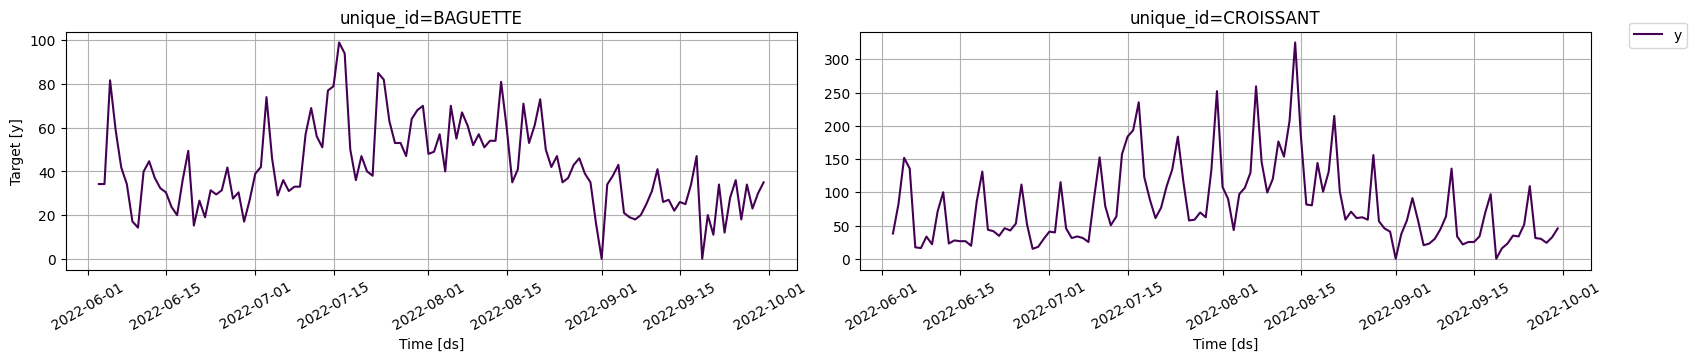

In [6]:
# 5. Exploratory analysis

series_lengths = (
    df.groupby(ID_COL)
      .size()
      .sort_values(ascending=False)
      .reset_index(name="n_obs")
)

print("\nTop series by length:")
print(series_lengths.head(10))

plot_series(
    df=df,
    ids=SELECTED_SERIES,
    max_insample_length=120,
    palette="viridis"
)

In [7]:
# 6. Holdout split

train_df, test_df = split_last_horizon(df, HORIZON)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (56057, 4)
Test shape: (847, 4)


In [8]:
# 7. Baseline models

baseline_models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=SEASON_LENGTH),
]

sf_baseline = StatsForecast(models=baseline_models, freq=FREQ, n_jobs=-1)
sf_baseline.fit(train_df[[ID_COL, DATE_COL, TARGET_COL]])

baseline_preds = sf_baseline.predict(h=HORIZON)
print("\nBaseline predictions:")
print(baseline_preds.head())


Baseline predictions:
    unique_id         ds  Naive  HistoricAverage  WindowAverage  SeasonalNaive
0  12 MACARON 2022-09-22    0.0         9.577465       1.428571           10.0
1  12 MACARON 2022-09-23    0.0         9.577465       1.428571            0.0
2  12 MACARON 2022-09-24    0.0         9.577465       1.428571            0.0
3  12 MACARON 2022-09-25    0.0         9.577465       1.428571            0.0
4  12 MACARON 2022-09-26    0.0         9.577465       1.428571            0.0



Baseline evaluation summary:
  metric     Naive  HistoricAverage  WindowAverage  SeasonalNaive
0    mae  6.107556         5.228439       5.011663       4.613636
1   rmse  8.182211         6.679193       6.786677       6.886620
2  smape  0.394245         0.657457       0.472801       0.334725


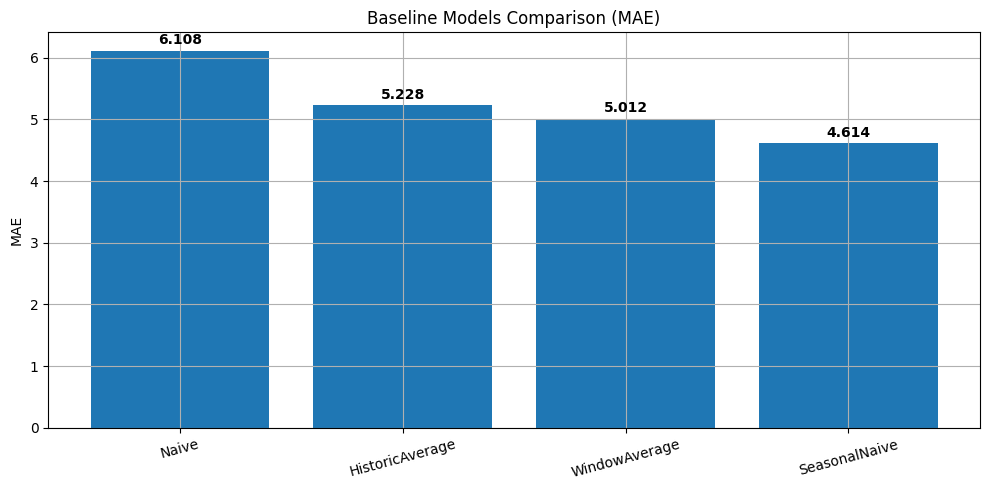

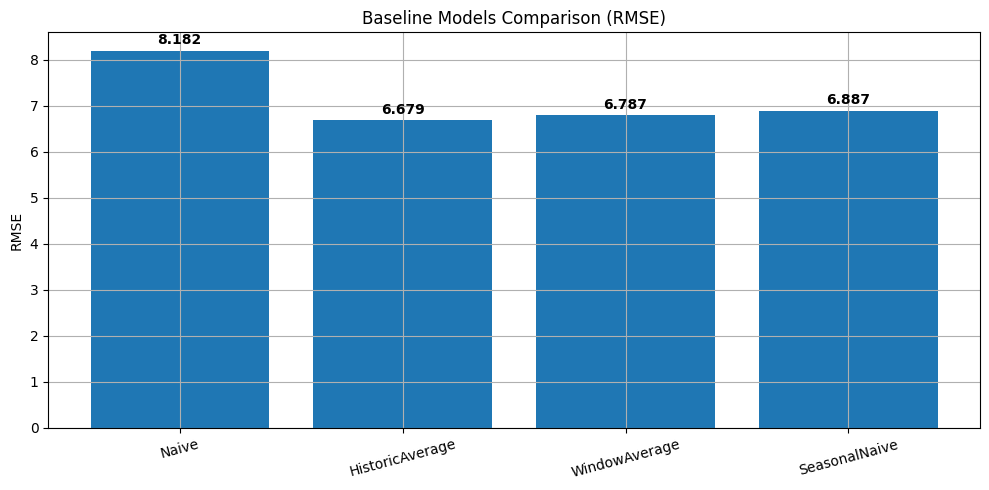

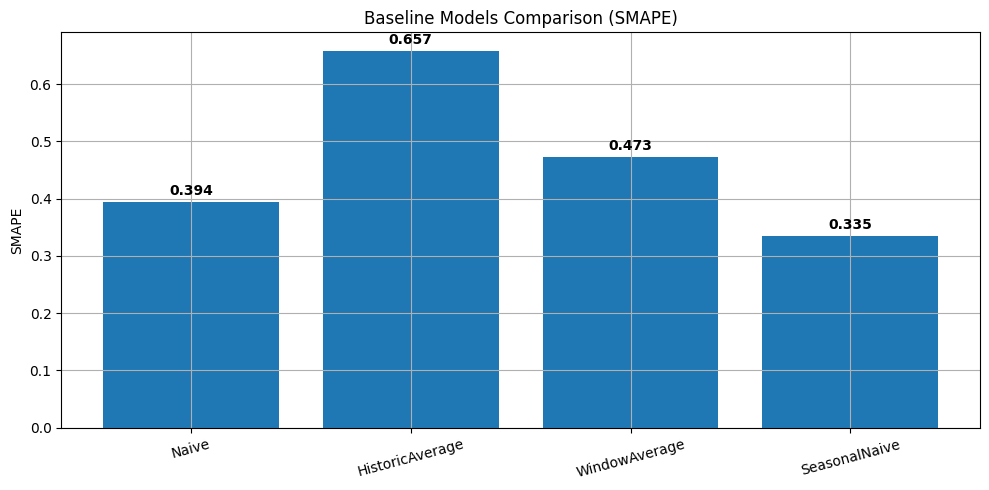

In [9]:
# 8. Evaluate baseline models

baseline_eval_df = test_df[[ID_COL, DATE_COL, TARGET_COL]].merge(
    baseline_preds,
    on=[ID_COL, DATE_COL],
    how="left"
)

baseline_eval = evaluate(
    baseline_eval_df,
    metrics=[mae, rmse, smape]
)

baseline_eval_summary = summarize_evaluation(baseline_eval)

print("\nBaseline evaluation summary:")
print(baseline_eval_summary)

plot_metric_bar(baseline_eval_summary, "mae", "Baseline Models Comparison (MAE)")
plot_metric_bar(baseline_eval_summary, "rmse", "Baseline Models Comparison (RMSE)")
plot_metric_bar(baseline_eval_summary, "smape", "Baseline Models Comparison (SMAPE)")


Advanced model evaluation summary:
  metric      ARIMA     SARIMA
0    mae  11.959274   8.904113
1   rmse  17.908375  10.742488
2  smape   0.162727   0.127719


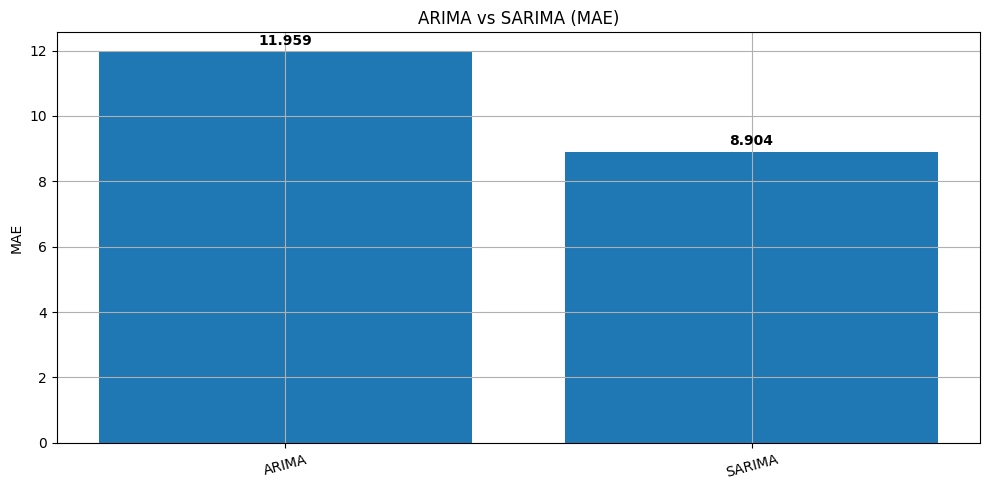

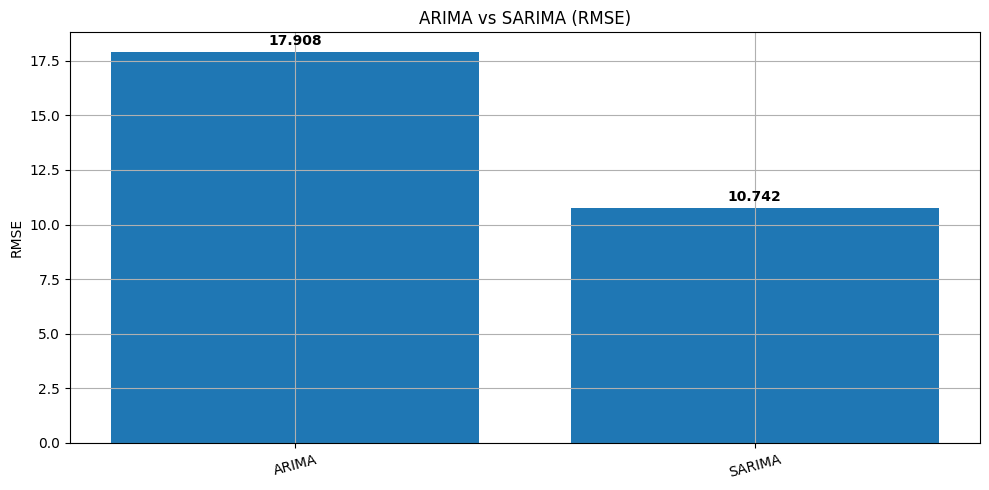

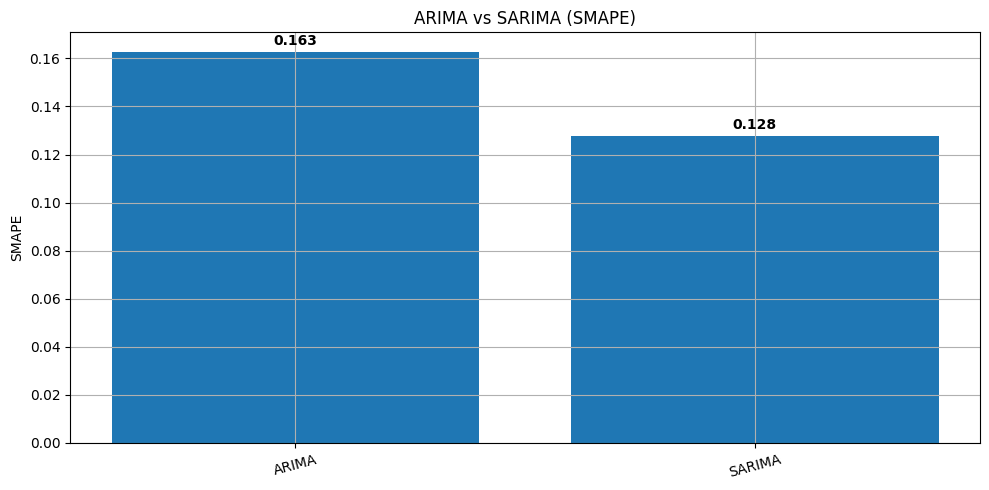

In [10]:
# 9. Advanced models on selected products

small_train = train_df[train_df[ID_COL].isin(SELECTED_SERIES)].copy()
small_test = test_df[test_df[ID_COL].isin(SELECTED_SERIES)].copy()

advanced_models = [
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=SEASON_LENGTH, alias="SARIMA"),
]

sf_advanced = StatsForecast(models=advanced_models, freq=FREQ, n_jobs=-1)
sf_advanced.fit(small_train[[ID_COL, DATE_COL, TARGET_COL]])

advanced_preds = sf_advanced.predict(h=HORIZON)

advanced_eval_df = small_test[[ID_COL, DATE_COL, TARGET_COL]].merge(
    advanced_preds,
    on=[ID_COL, DATE_COL],
    how="left"
)

advanced_eval = evaluate(
    advanced_eval_df,
    metrics=[mae, rmse, smape]
)

advanced_eval_summary = summarize_evaluation(advanced_eval)

print("\nAdvanced model evaluation summary:")
print(advanced_eval_summary)

plot_series(
    df=small_train,
    forecasts_df=advanced_preds,
    ids=SELECTED_SERIES,
    max_insample_length=60,
    palette="viridis"
)

plot_metric_bar(advanced_eval_summary, "mae", "ARIMA vs SARIMA (MAE)")
plot_metric_bar(advanced_eval_summary, "rmse", "ARIMA vs SARIMA (RMSE)")
plot_metric_bar(advanced_eval_summary, "smape", "ARIMA vs SARIMA (SMAPE)")


Cross-validation sample:
  unique_id         ds     cutoff     y  SeasonalNaive      ARIMA     SARIMA
0  BAGUETTE 2022-08-06 2022-08-05  55.0           68.0  71.355196  71.584713
1  BAGUETTE 2022-08-07 2022-08-05  67.0           70.0  70.337980  78.458883
2  BAGUETTE 2022-08-08 2022-08-05  61.0           48.0  61.195004  57.001732
3  BAGUETTE 2022-08-09 2022-08-05  52.0           49.0  52.649013  49.401144
4  BAGUETTE 2022-08-10 2022-08-05  57.0           57.0  47.785876  49.725278

Cross-validation summary:
  metric  SeasonalNaive      ARIMA     SARIMA
0    mae      21.117857  21.170930  19.281296
1   rmse      27.875413  28.372740  25.230597
2  smape       0.211317   0.183609   0.166574


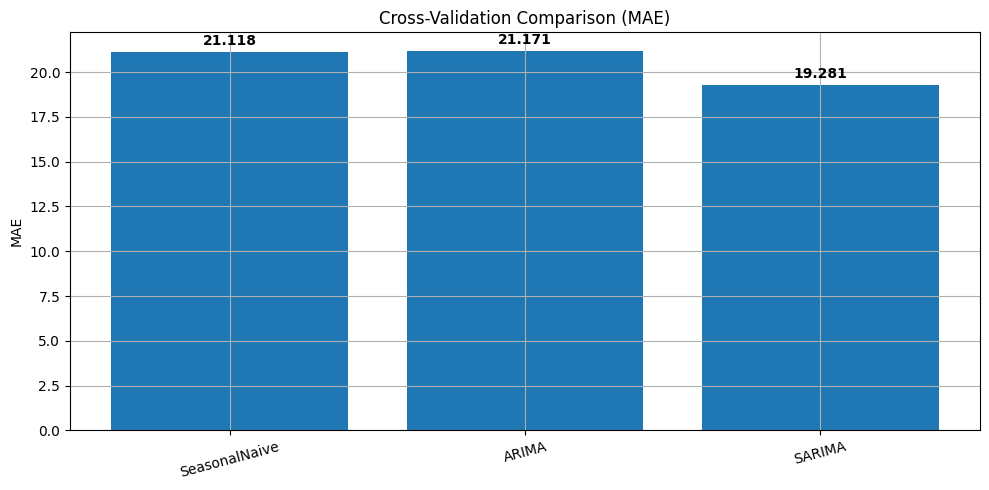

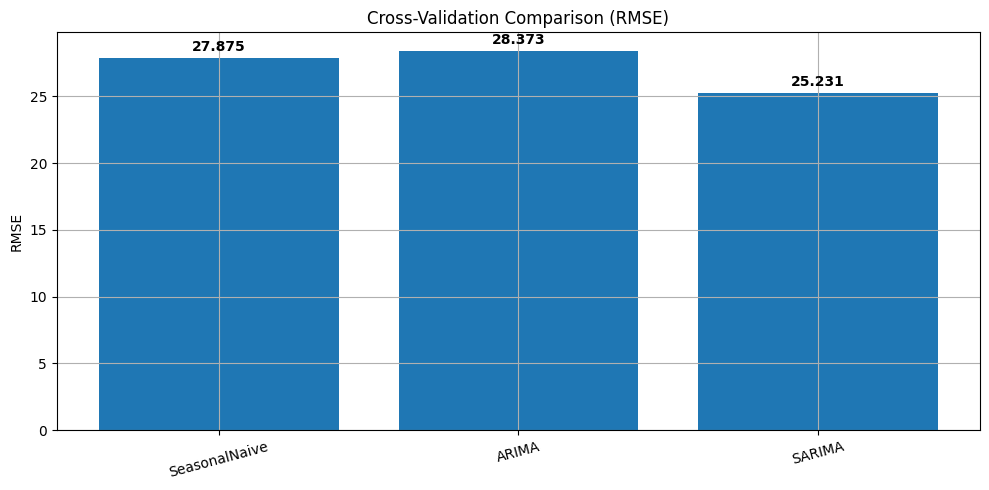

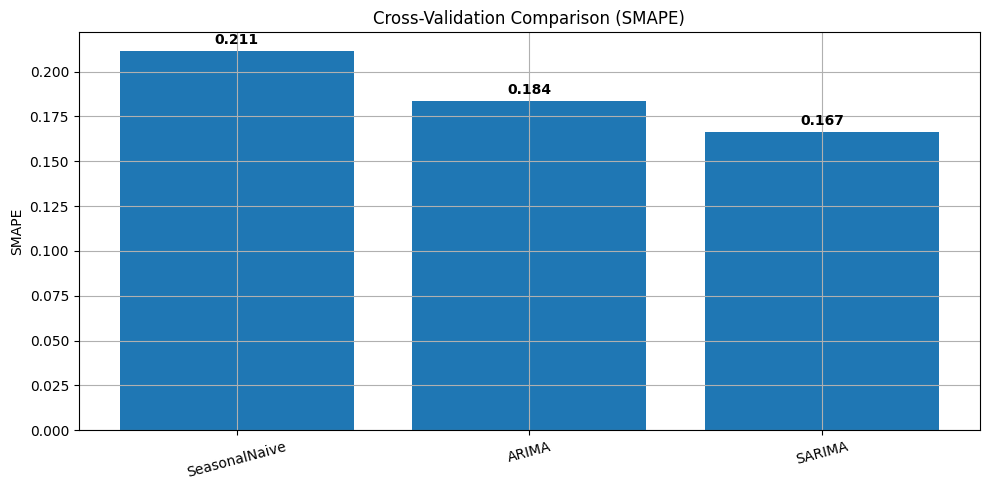

In [11]:
# 10. Rolling cross-validation

small_df = df[df[ID_COL].isin(SELECTED_SERIES)].copy()

cv_models = [
    SeasonalNaive(season_length=SEASON_LENGTH),
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=SEASON_LENGTH, alias="SARIMA"),
]

sf_cv = StatsForecast(models=cv_models, freq=FREQ, n_jobs=-1)

cv_df = sf_cv.cross_validation(
    df=small_df[[ID_COL, DATE_COL, TARGET_COL]],
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
    refit=True,
)

print("\nCross-validation sample:")
print(cv_df.head())

cv_eval = evaluate(
    cv_df.drop(columns=["cutoff"]),
    metrics=[mae, rmse, smape]
)

cv_eval_summary = summarize_evaluation(cv_eval)

print("\nCross-validation summary:")
print(cv_eval_summary)

plot_series(
    df=small_df,
    forecasts_df=cv_df.drop(columns=["y", "cutoff"]),
    ids=SELECTED_SERIES,
    max_insample_length=140,
    palette="viridis"
)

plot_metric_bar(cv_eval_summary, "mae", "Cross-Validation Comparison (MAE)")
plot_metric_bar(cv_eval_summary, "rmse", "Cross-Validation Comparison (RMSE)")
plot_metric_bar(cv_eval_summary, "smape", "Cross-Validation Comparison (SMAPE)")


Price exogenous comparison summary:
  metric  SARIMA_price_exog     SARIMA
0    mae           8.865536   8.904113
1   rmse          10.722380  10.742488
2  smape           0.124361   0.127719


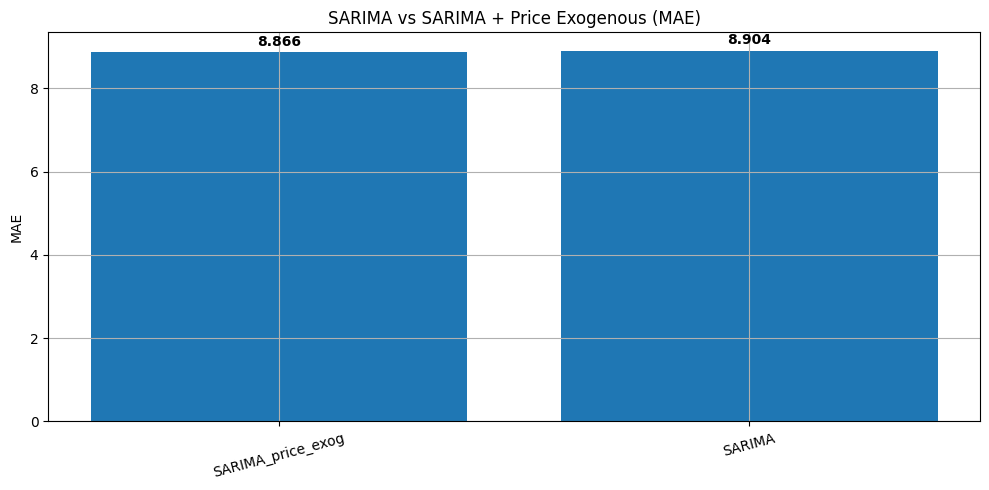

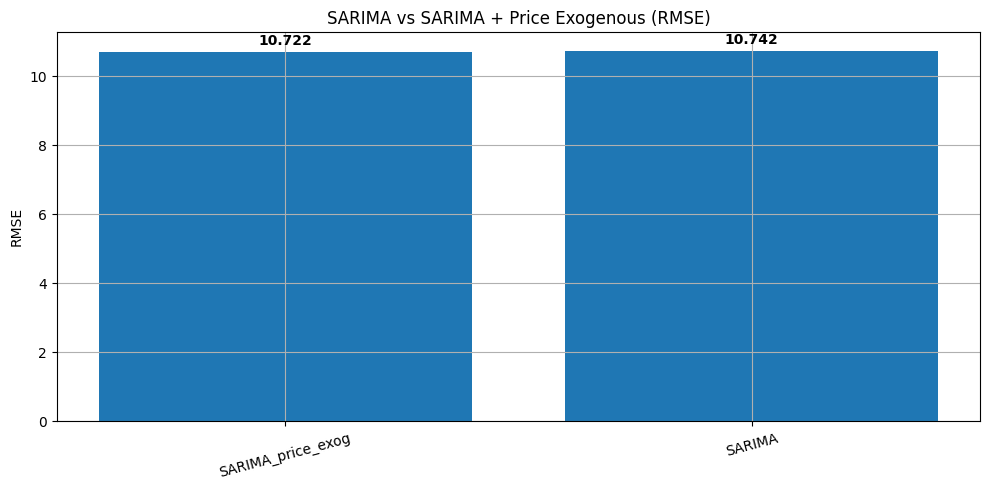

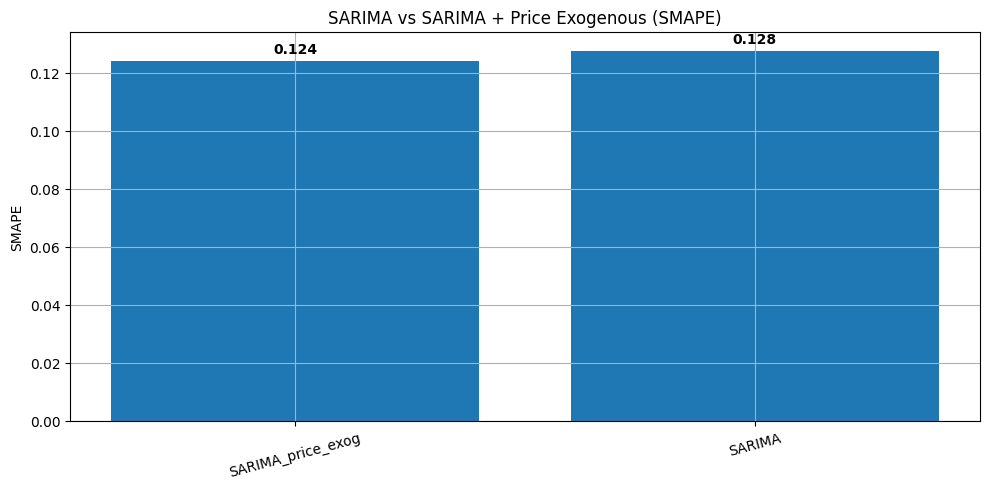

In [12]:
# 11. Forecasting with price as exogenous variable

df_exog = load_data(DATA_URL)
df_exog = df_exog[df_exog[ID_COL].isin(SELECTED_SERIES)].copy()

train_exog, test_exog = split_last_horizon(df_exog, HORIZON)
futr_exog_df = test_exog.drop(columns=[TARGET_COL]).copy()

# SARIMA with price exogenous feature
sf_price_exog = StatsForecast(
    models=[AutoARIMA(season_length=SEASON_LENGTH, alias="SARIMA_price_exog")],
    freq=FREQ,
    n_jobs=-1
)

sf_price_exog.fit(train_exog[[ID_COL, DATE_COL, TARGET_COL, "unit_price"]])
price_exog_preds = sf_price_exog.predict(
    h=HORIZON,
    X_df=futr_exog_df[[ID_COL, DATE_COL, "unit_price"]]
)

# Plain SARIMA for comparison
sf_plain_sarima = StatsForecast(
    models=[AutoARIMA(season_length=SEASON_LENGTH, alias="SARIMA")],
    freq=FREQ,
    n_jobs=-1
)

sf_plain_sarima.fit(train_exog[[ID_COL, DATE_COL, TARGET_COL]])
plain_sarima_preds = sf_plain_sarima.predict(h=HORIZON)

compare_exog_df = (
    test_exog[[ID_COL, DATE_COL, TARGET_COL, "unit_price"]]
    .merge(price_exog_preds, on=[ID_COL, DATE_COL], how="left")
    .merge(plain_sarima_preds, on=[ID_COL, DATE_COL], how="left")
)

exog_eval = evaluate(
    compare_exog_df.drop(columns=["unit_price"]),
    metrics=[mae, rmse, smape]
)

exog_eval_summary = summarize_evaluation(exog_eval)

print("\nPrice exogenous comparison summary:")
print(exog_eval_summary)

plot_series(
    df=train_exog,
    forecasts_df=compare_exog_df,
    ids=SELECTED_SERIES,
    models=["SARIMA_price_exog", "SARIMA"],
    max_insample_length=60,
    palette="viridis"
)

plot_metric_bar(exog_eval_summary, "mae", "SARIMA vs SARIMA + Price Exogenous (MAE)")
plot_metric_bar(exog_eval_summary, "rmse", "SARIMA vs SARIMA + Price Exogenous (RMSE)")
plot_metric_bar(exog_eval_summary, "smape", "SARIMA vs SARIMA + Price Exogenous (SMAPE)")

In [13]:
# 12. Forecasting with engineered time features

feature_builders = [
    partial(fourier, season_length=7, k=2),
    partial(time_features, features=["day", "week", "month"])
]

small_exog_df, future_time_df = pipeline(
    df=df_exog,
    features=feature_builders,
    freq=FREQ,
    h=HORIZON
)

sf_time_exog = StatsForecast(
    models=[AutoARIMA(season_length=SEASON_LENGTH, alias="SARIMA_time_exog")],
    freq=FREQ,
    n_jobs=-1
)

time_exog_cv_df = sf_time_exog.cross_validation(
    df=small_exog_df,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
    refit=True
)

time_exog_eval = evaluate(
    time_exog_cv_df.drop(columns=["cutoff"]),
    metrics=[mae, rmse, smape]
)

time_exog_eval_summary = summarize_evaluation(time_exog_eval)

print("\nTime feature model summary:")
print(time_exog_eval_summary)


Time feature model summary:
  metric  SARIMA_time_exog
0    mae         19.721581
1   rmse         25.855366
2  smape          0.179144


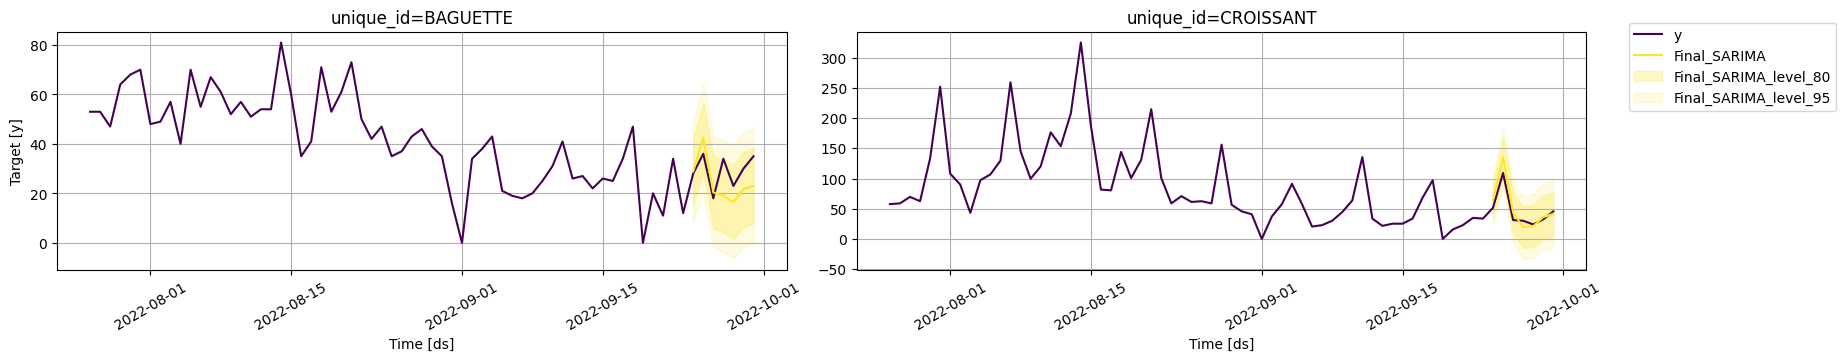

In [14]:
# 13. Prediction intervals with final model

sf_intervals = StatsForecast(
    models=[AutoARIMA(season_length=SEASON_LENGTH, alias="Final_SARIMA")],
    freq=FREQ,
    n_jobs=-1
)

sf_intervals.fit(train_exog[[ID_COL, DATE_COL, TARGET_COL, "unit_price"]])

interval_preds = sf_intervals.predict(
    h=HORIZON,
    X_df=futr_exog_df[[ID_COL, DATE_COL, "unit_price"]],
    level=[80, 95]
)

interval_test_df = test_exog.merge(interval_preds, on=[ID_COL, DATE_COL], how="left")

plot_series(
    df=train_exog,
    forecasts_df=interval_test_df,
    ids=SELECTED_SERIES,
    models=["Final_SARIMA"],
    level=[80, 95],
    max_insample_length=60,
    palette="viridis"
)

In [15]:
# 14. Final evaluation with more metrics

final_models = [
    AutoARIMA(season_length=SEASON_LENGTH, alias="SARIMA_exog"),
    SeasonalNaive(season_length=SEASON_LENGTH),
]

sf_final = StatsForecast(models=final_models, freq=FREQ, n_jobs=-1)

final_cv_df = sf_final.cross_validation(
    df=df_exog[[ID_COL, DATE_COL, TARGET_COL, "unit_price"]],
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
    refit=True,
    level=[80],
)

temp_test = df_exog.groupby(ID_COL).tail(HORIZON * N_WINDOWS)
temp_train = df_exog.drop(temp_test.index).reset_index(drop=True)

final_metrics = [
    mae,
    mse,
    rmse,
    mape,
    smape,
    partial(mase, seasonality=SEASON_LENGTH),
    scaled_crps,
]

final_eval = evaluate(
    final_cv_df.drop(columns=["ds", "cutoff"]),
    metrics=final_metrics,
    models=["SARIMA_exog", "SeasonalNaive"],
    train_df=temp_train,
    level=[80],
)

final_eval_summary = (
    final_eval.drop(columns=[ID_COL])
    .groupby("metric")
    .mean()
    .reset_index()
)

print("\nFinal evaluation summary:")
print(final_eval_summary)


Final evaluation summary:
        metric  SARIMA_exog  SeasonalNaive
0          mae    19.211687      21.117857
1         mape     0.328615       0.376819
2         mase     1.181499       1.328592
3          mse   792.788111     970.417143
4         rmse    24.979598      27.875413
5  scaled_crps     0.153636       0.166451
6        smape     0.168241       0.211317


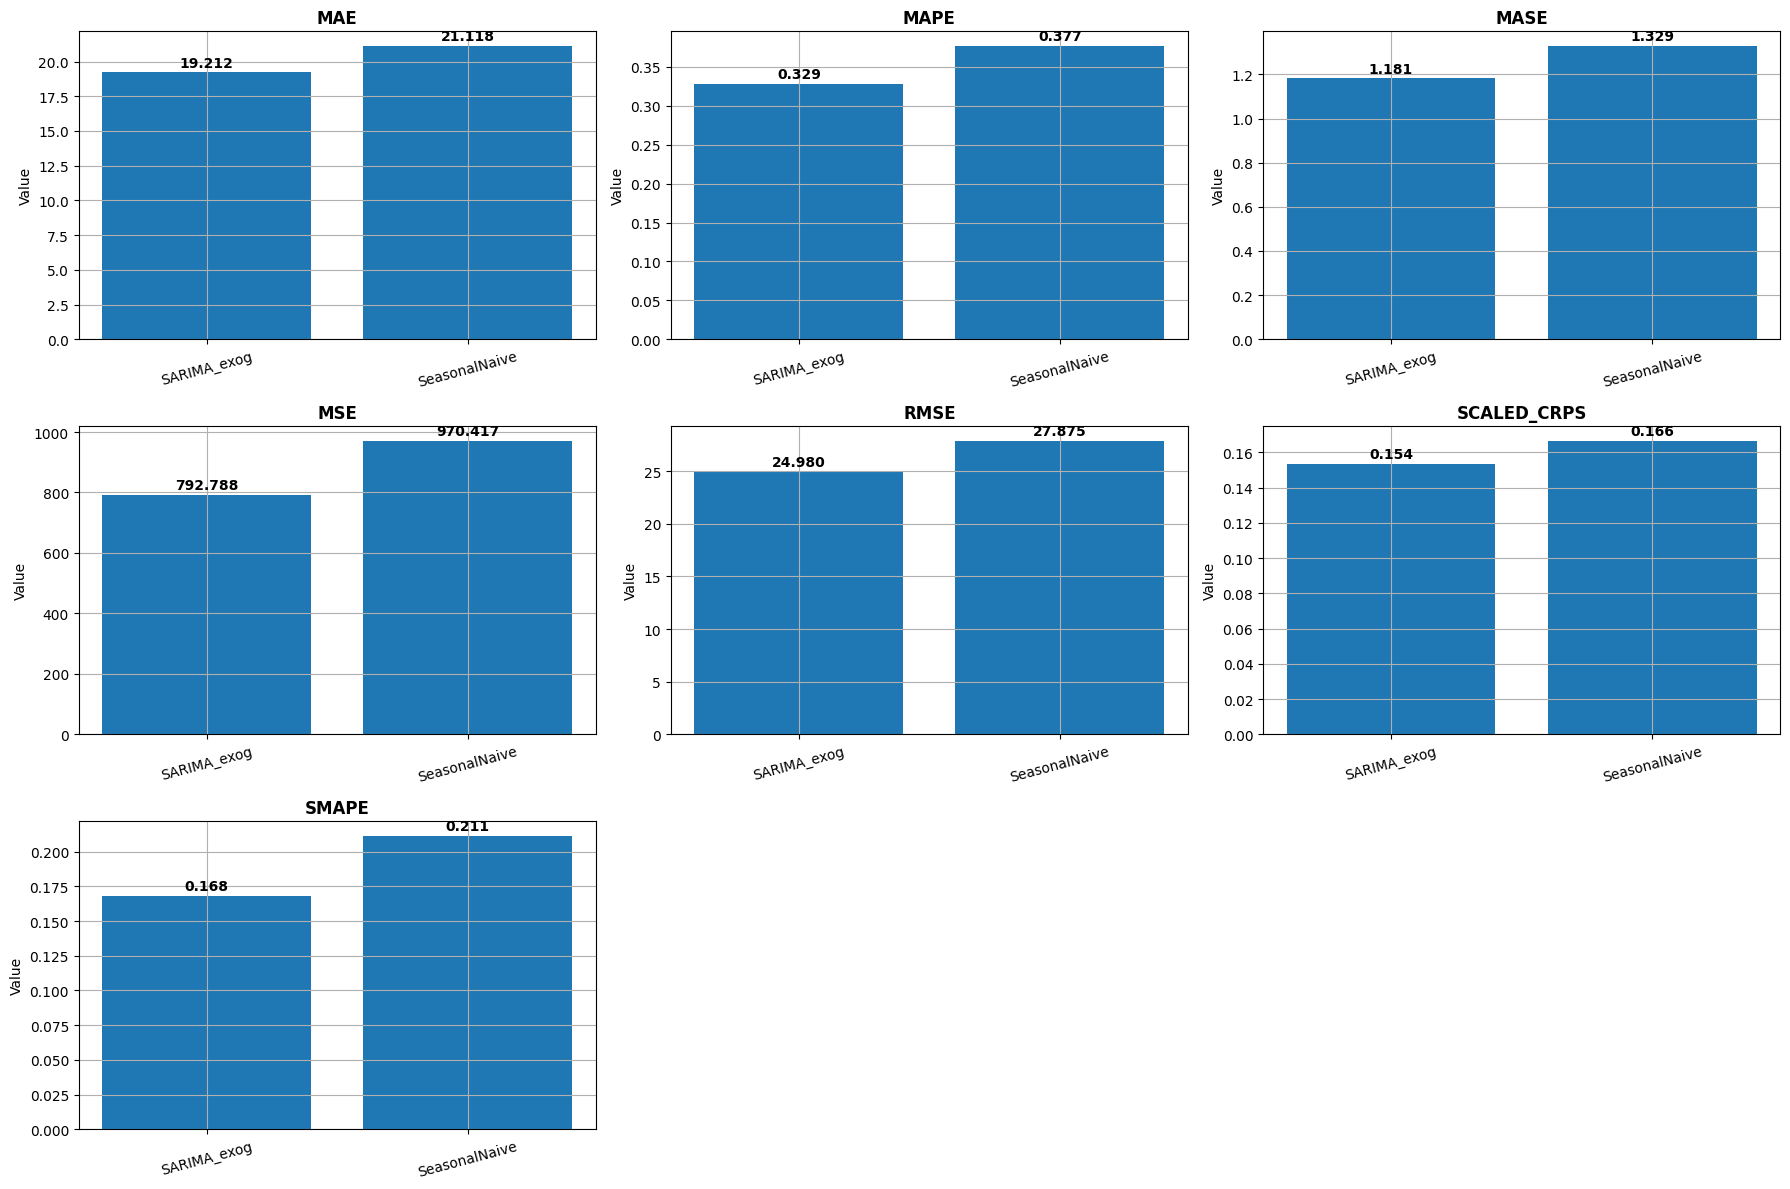

In [16]:
# 15. Final metric comparison plots

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, row in final_eval_summary.iterrows():
    ax = axes[i]
    values = [row["SARIMA_exog"], row["SeasonalNaive"]]
    labels = ["SARIMA_exog", "SeasonalNaive"]

    bars = ax.bar(labels, values)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10
        )

    ax.set_title(row["metric"].upper(), fontweight="bold")
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", rotation=15)

for j in range(len(final_eval_summary), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
# 16. Simple comparison table of all models used

# Note:
# Baseline model values come from holdout evaluation across all products.
# ARIMA/SARIMA values come from selected-series holdout evaluation.
# Time-feature model values come from cross-validation on selected series.
# This table is meant as a simple summary for notebook presentation.

baseline_mae = baseline_eval_summary.loc[baseline_eval_summary["metric"] == "mae"].iloc[0]
baseline_rmse = baseline_eval_summary.loc[baseline_eval_summary["metric"] == "rmse"].iloc[0]
baseline_smape = baseline_eval_summary.loc[baseline_eval_summary["metric"] == "smape"].iloc[0]

advanced_mae = advanced_eval_summary.loc[advanced_eval_summary["metric"] == "mae"].iloc[0]
advanced_rmse = advanced_eval_summary.loc[advanced_eval_summary["metric"] == "rmse"].iloc[0]
advanced_smape = advanced_eval_summary.loc[advanced_eval_summary["metric"] == "smape"].iloc[0]

cv_mae = cv_eval_summary.loc[cv_eval_summary["metric"] == "mae"].iloc[0]
cv_rmse = cv_eval_summary.loc[cv_eval_summary["metric"] == "rmse"].iloc[0]
cv_smape = cv_eval_summary.loc[cv_eval_summary["metric"] == "smape"].iloc[0]

exog_mae = exog_eval_summary.loc[exog_eval_summary["metric"] == "mae"].iloc[0]
exog_rmse = exog_eval_summary.loc[exog_eval_summary["metric"] == "rmse"].iloc[0]
exog_smape = exog_eval_summary.loc[exog_eval_summary["metric"] == "smape"].iloc[0]

time_mae = time_exog_eval_summary.loc[time_exog_eval_summary["metric"] == "mae"].iloc[0]
time_rmse = time_exog_eval_summary.loc[time_exog_eval_summary["metric"] == "rmse"].iloc[0]
time_smape = time_exog_eval_summary.loc[time_exog_eval_summary["metric"] == "smape"].iloc[0]

comparison_rows = [
    {
        "Model": "Naive",
        "Category": "Baseline",
        "MAE": float(baseline_mae["Naive"]),
        "RMSE": float(baseline_rmse["Naive"]),
        "SMAPE": float(baseline_smape["Naive"]),
    },
    {
        "Model": "Historic Average",
        "Category": "Baseline",
        "MAE": float(baseline_mae["HistoricAverage"]),
        "RMSE": float(baseline_rmse["HistoricAverage"]),
        "SMAPE": float(baseline_smape["HistoricAverage"]),
    },
    {
        "Model": "Window Average (7)",
        "Category": "Baseline",
        "MAE": float(baseline_mae["WindowAverage"]),
        "RMSE": float(baseline_rmse["WindowAverage"]),
        "SMAPE": float(baseline_smape["WindowAverage"]),
    },
    {
        "Model": "Seasonal Naive",
        "Category": "Baseline / CV",
        "MAE": float(cv_mae["SeasonalNaive"]),
        "RMSE": float(cv_rmse["SeasonalNaive"]),
        "SMAPE": float(cv_smape["SeasonalNaive"]),
    },
    {
        "Model": "ARIMA",
        "Category": "Advanced / CV",
        "MAE": float(cv_mae["ARIMA"]),
        "RMSE": float(cv_rmse["ARIMA"]),
        "SMAPE": float(cv_smape["ARIMA"]),
    },
    {
        "Model": "SARIMA",
        "Category": "Advanced / CV",
        "MAE": float(cv_mae["SARIMA"]),
        "RMSE": float(cv_rmse["SARIMA"]),
        "SMAPE": float(cv_smape["SARIMA"]),
    },
    {
        "Model": "SARIMA + Price Exogenous",
        "Category": "Advanced + Exogenous",
        "MAE": float(exog_mae["SARIMA_price_exog"]),
        "RMSE": float(exog_rmse["SARIMA_price_exog"]),
        "SMAPE": float(exog_smape["SARIMA_price_exog"]),
    },
    {
        "Model": "SARIMA + Time Features",
        "Category": "Advanced + Feature Engineering",
        "MAE": float(time_mae["SARIMA_time_exog"]),
        "RMSE": float(time_rmse["SARIMA_time_exog"]),
        "SMAPE": float(time_smape["SARIMA_time_exog"]),
    },
]

comparison_df = build_comparison_table(comparison_rows)

print("\nModel comparison table:")
print(comparison_df)


Model comparison table:
   Rank                     Model                        Category        MAE  \
0     1        Window Average (7)                        Baseline   5.011663   
1     2          Historic Average                        Baseline   5.228439   
2     3                     Naive                        Baseline   6.107556   
3     4  SARIMA + Price Exogenous            Advanced + Exogenous   8.865536   
4     5                    SARIMA                   Advanced / CV  19.281296   
5     6    SARIMA + Time Features  Advanced + Feature Engineering  19.721581   
6     7            Seasonal Naive                   Baseline / CV  21.117857   
7     8                     ARIMA                   Advanced / CV  21.170930   

        RMSE     SMAPE  
0   6.786677  0.472801  
1   6.679193  0.657457  
2   8.182211  0.394245  
3  10.722380  0.124361  
4  25.230597  0.166574  
5  25.855366  0.179144  
6  27.875413  0.211317  
7  28.372740  0.183609  


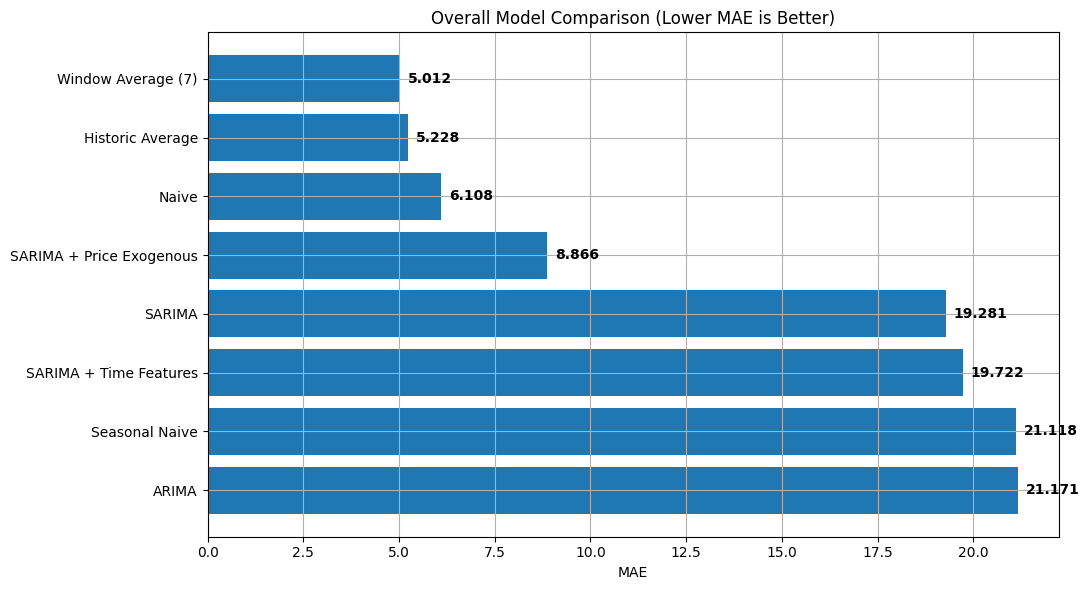

In [18]:
# 17. Visualize comparison table results

plt.figure(figsize=(11, 6))
bars = plt.barh(comparison_df["Model"], comparison_df["MAE"])

for bar, val in zip(bars, comparison_df["MAE"]):
    plt.text(
        val + max(comparison_df["MAE"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontweight="bold"
    )

plt.gca().invert_yaxis()
plt.xlabel("MAE")
plt.title("Overall Model Comparison (Lower MAE is Better)")
plt.tight_layout()
plt.show()

In [19]:
# 18. Select best model automatically

best_model_row = comparison_df.iloc[0]
print("\nBest model based on MAE:")
print(best_model_row)


Best model based on MAE:
Rank                         1
Model       Window Average (7)
Category              Baseline
MAE                   5.011663
RMSE                  6.786677
SMAPE                 0.472801
Name: 0, dtype: object


In [20]:
# 19. Train final model on full history and forecast next 7 days

final_train_df = df_exog.copy()

# Build future exogenous dataframe using latest available price
future_dates = pd.date_range(
    start=final_train_df[DATE_COL].max() + pd.Timedelta(days=1),
    periods=HORIZON,
    freq=FREQ
)

latest_prices = (
    final_train_df.sort_values([ID_COL, DATE_COL])
    .groupby(ID_COL)
    .tail(1)[[ID_COL, "unit_price"]]
)

future_rows = []
for product in final_train_df[ID_COL].unique():
    product_price = latest_prices.loc[latest_prices[ID_COL] == product, "unit_price"].iloc[0]
    for d in future_dates:
        future_rows.append({
            ID_COL: product,
            DATE_COL: d,
            "unit_price": product_price
        })

future_df = pd.DataFrame(future_rows)

best_forecast_model = StatsForecast(
    models=[AutoARIMA(season_length=SEASON_LENGTH, alias="Best_Model")],
    freq=FREQ,
    n_jobs=-1
)

best_forecast_model.fit(final_train_df[[ID_COL, DATE_COL, TARGET_COL, "unit_price"]])

future_forecasts = best_forecast_model.predict(
    h=HORIZON,
    X_df=future_df,
    level=[80, 95]
)

print("\nFuture forecasts:")
print(future_forecasts.head(20))


Future forecasts:
    unique_id         ds  Best_Model  Best_Model-lo-95  Best_Model-lo-80  \
0    BAGUETTE 2022-10-01   38.726947         18.504396         25.504131   
1    BAGUETTE 2022-10-02   48.201507         26.551768         34.045503   
2    BAGUETTE 2022-10-03   27.886760          5.705041         13.382914   
3    BAGUETTE 2022-10-04   27.688092          5.136131         12.942157   
4    BAGUETTE 2022-10-05   23.851207          0.982618          8.898240   
5    BAGUETTE 2022-10-06   27.820811          4.666508         12.681026   
6    BAGUETTE 2022-10-07   31.516017          8.100363         16.205344   
7   CROISSANT 2022-10-01   70.290355         28.247551         42.800043   
8   CROISSANT 2022-10-02  137.384111         89.560219        106.113749   
9   CROISSANT 2022-10-03   47.008657         -3.350121         14.080822   
10  CROISSANT 2022-10-04   25.729942        -26.261311         -8.265311   
11  CROISSANT 2022-10-05   25.997961        -27.252940         -8.820

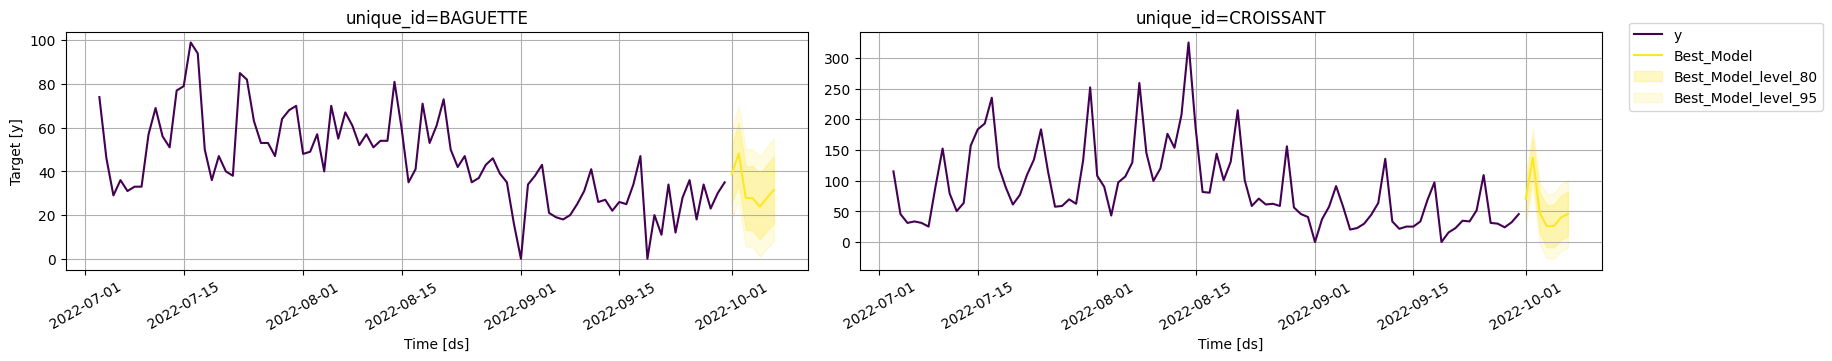

In [21]:
# 20. Plot final future forecasts

plot_series(
    df=final_train_df,
    forecasts_df=future_forecasts,
    ids=SELECTED_SERIES,
    models=["Best_Model"],
    level=[80, 95],
    max_insample_length=90,
    palette="viridis"
)